# TP1 — Sentiment Classification on French Movie Reviews (Allociné)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/L2Math/blob/main/session5/tp1_correction.ipynb)

## Objective

In this TP we will:
1. Load and explore a **text dataset** (French movie reviews)
2. Clean and preprocess text data
3. Convert text to numerical features using **TF-IDF vectorization**
4. Train a **Logistic Regression** classifier on text
5. Interpret the model by examining learned coefficients

### Dataset: Allociné Movie Reviews

We use a subset of the **Allociné** dataset — 5,000 French movie reviews labeled as **positive** (1) or **negative** (0).

### New Concepts

| Concept | Description |
|---------|-------------|
| **TF-IDF** | Term Frequency–Inverse Document Frequency — weights words by how important they are in a document relative to the corpus |
| **Vectorization** | Converting text into a numerical matrix that models can use |
| **Stopwords** | Common words ("le", "de", "est") that carry little meaning |
| **n-grams** | Sequences of n consecutive words — bigrams capture phrases like "pas bon" |

---
## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
import warnings
warnings.filterwarnings('ignore')

---
## 2. Data Loading & Exploration

We use pre-sampled CSVs from the Allociné dataset (5k train / 1k test). Each row has:
- `review` — the movie review text (French)
- `label` — 0 (negative) or 1 (positive)

### Exercise 1.1 — Load the data

Load the train and test CSVs and display the shape, columns, and first 5 rows.

*Hint:* `pd.read_csv(url)` can load directly from a URL.

In [4]:
train_url = "allocine_train.csv"
test_url = "allocine_test.csv"

train = pd.read_csv(train_url)
test = pd.read_csv(test_url)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Columns: {list(train.columns)}")
print()
train.head()

Train shape: (5000, 2)
Test shape: (1000, 2)
Columns: ['review', 'label']



,review,label
0,Ray Milland qui a tourné dans presque 200 film...,0
1,le film est très mauvais car : trop peu d'acti...,0
2,aie aie aie! En corse ça passait encore! Mais ...,0
3,Encore un film iranien. Au fil des films qui a...,1
4,Je ne me lancerai pas dans une analyse fine su...,0


### Exercise 1.2 — Class balance

Check the distribution of positive vs negative reviews in the training set.

*Hint:* `df['label'].value_counts(normalize=True)`

In [5]:
print("Class counts:")
print(train['label'].value_counts())
print()
print("Class proportions:")
print(train['label'].value_counts(normalize=True))

Class counts:
label
0    2538
1    2462
Name: count, dtype: int64

Class proportions:
label
0    0.5076
1    0.4924
Name: proportion, dtype: float64


### Exercise 1.3 — Review length distribution

Compute the number of words per review and plot a histogram of review lengths, colored by label.

*Hint:* `df['n_words'] = df['review'].apply(lambda x: len(x.split()))`, then `sns.histplot(..., hue='label')`

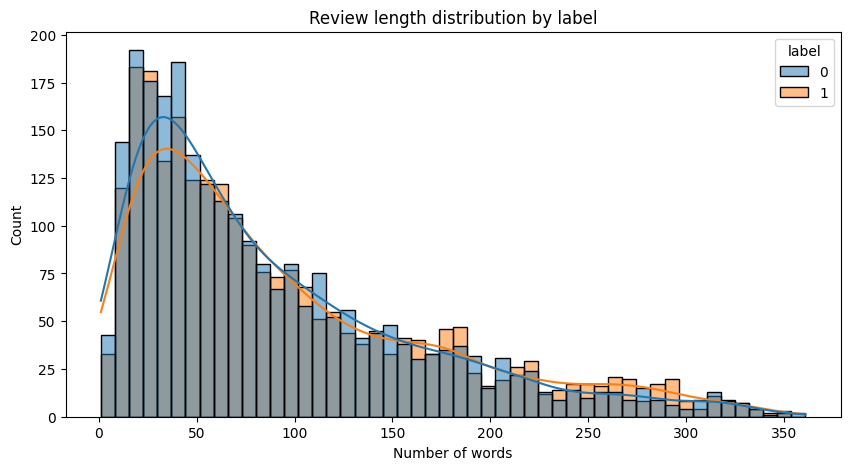

Mean words: 92
Median words: 67
Min: 1, Max: 361


In [6]:
train['n_words'] = train['review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(data=train, x='n_words', hue='label', bins=50, kde=True)
plt.xlabel('Number of words')
plt.ylabel('Count')
plt.title('Review length distribution by label')
plt.show()

print(f"Mean words: {train['n_words'].mean():.0f}")
print(f"Median words: {train['n_words'].median():.0f}")
print(f"Min: {train['n_words'].min()}, Max: {train['n_words'].max()}")

### Exercise 1.4 — Sample reviews

Display 3 positive and 3 negative reviews to get a feel for the data.

*Hint:* `df[df['label'] == 1]['review'].head(3)`

In [7]:
print("=== POSITIVE REVIEWS ===")
for i, row in train[train['label'] == 1].head(3).iterrows():
    print(f"[{i}] {row['review'][:300]}...")
    print()

print("=== NEGATIVE REVIEWS ===")
for i, row in train[train['label'] == 0].head(3).iterrows():
    print(f"[{i}] {row['review'][:300]}...")
    print()

=== POSITIVE REVIEWS ===
[3] Encore un film iranien. Au fil des films qui arrivent en France, cette société islamique que nous ne comprenons pas, nous livre ses petits secrets et ses incohérences. Par exemple le changement de sexe est autorisé et même remboursé par l’état, un comble pour un pays dont la femme est considérée com...

[5] Grâce à sa réalisation d'une remarquable qualité, "April Snow" parvient à nous envouter dès la première minute. Certes, certains pourront trouver ça un peu scolaire parfois, mais on ne peut nier l'efficacité de chaque plan, de chaque situation, de chaque silence. Jin-Ho Hur sait tirer au maximum par...

[7] Un ex-flic est infiltré dans une prison où des combats clandestins se déroulent. Ring of death multiplie les références aux poncifs du genre. Parmi eux, In hell, Coups pour coups, Scorpion... Le directeur de la prison imbu de sa propre personne et arrogant fait penser à Donald Sutherland dans Haute ...

=== NEGATIVE REVIEWS ===
[0] Ray Milland qui a t

---
## 3. Text Cleaning

Before vectorizing, we clean the text to reduce noise. Common preprocessing steps:
- **Lowercase** — so "Bon" and "bon" are the same token
- **Remove HTML tags** — leftover markup from web scraping
- **Remove URLs** — links carry no sentiment
- **Remove special characters and digits** — keep only letters and spaces

### Exercise 2.1 — Write a cleaning function

Write a function `clean_text(text)` that:
1. Converts to lowercase
2. Removes HTML tags (`<...>`)
3. Removes URLs
4. Removes digits
5. Removes special characters (keep only letters, accented characters, and spaces)

Apply it to the train and test review columns.

*Hint:*
```python
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)        # HTML tags
    text = re.sub(r'http\S+', ' ', text)         # URLs
    text = re.sub(r'\d+', ' ', text)              # digits
    text = re.sub(r'[^a-zàâäéèêëïîôùûüÿçœæ\s]', ' ', text)  # keep letters + accents
    text = re.sub(r'\s+', ' ', text).strip()      # multiple spaces
    return text
```

In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)        # HTML tags
    text = re.sub(r'http\S+', ' ', text)         # URLs
    text = re.sub(r'\d+', ' ', text)              # digits
    text = re.sub(r'[^a-zàâäéèêëïîôùûüÿçœæ\s]', ' ', text)  # keep letters + accents
    text = re.sub(r'\s+', ' ', text).strip()      # multiple spaces
    return text

train['review_clean'] = train['review'].apply(clean_text)
test['review_clean'] = test['review'].apply(clean_text)

print("Cleaning done.")
print(f"Train: {len(train)} reviews")
print(f"Test: {len(test)} reviews")

Cleaning done.
Train: 5000 reviews
Test: 1000 reviews


### Exercise 2.2 — Before / after comparison

Show the original and cleaned version of 3 reviews side by side.

*Hint:* Print pairs of `df['review'].iloc[i]` and `df['review_clean'].iloc[i]`

In [9]:
for i in range(3):
    print(f"--- Review {i} ---")
    print(f"ORIGINAL: {train['review'].iloc[i][:200]}")
    print(f"CLEANED:  {train['review_clean'].iloc[i][:200]}")
    print()

--- Review 0 ---
ORIGINAL: Ray Milland qui a tourné dans presque 200 films s'est amusé à en réaliser 5.Celui est est le plus connu mais pas le meilleur. Il y a certes quelques séquences réussies mais beaucoup trop qui semblent 
CLEANED:  ray milland qui a tourné dans presque films s est amusé à en réaliser celui est est le plus connu mais pas le meilleur il y a certes quelques séquences réussies mais beaucoup trop qui semblent fabriqu

--- Review 1 ---
ORIGINAL: le film est très mauvais car : trop peu d'actions effets spéciaux non tape-a-l’œil le perso principal est creux le jeu d'acteur n'est pas geniale toutefois le scenario est bon ( dans la norme ) je vou
CLEANED:  le film est très mauvais car trop peu d actions effets spéciaux non tape a l œil le perso principal est creux le jeu d acteur n est pas geniale toutefois le scenario est bon dans la norme je vous deco

--- Review 2 ---
ORIGINAL: aie aie aie! En corse ça passait encore! Mais là c'est encore plus déprimant que saint-Tropez

**Question:** Should we remove accents for French text? What about emojis? Numbers?

**Answer:**
- **Accents:** No — removing accents in French would merge distinct words (e.g., "où" vs "ou", "à" vs "a"). Accents carry meaning.
- **Emojis:** Could be useful for sentiment (😊 = positive), but TF-IDF on word tokens won't capture them well. Removing is fine for this approach.
- **Numbers:** Usually not informative for sentiment ("3 étoiles" → the word "étoiles" carries the signal). Removing digits is reasonable, though ratings like "10/10" could be useful.

---
## 4. Vectorization Experiments

**TF-IDF** (Term Frequency–Inverse Document Frequency) converts text into a numerical matrix:
- **TF**: how often a word appears in a document
- **IDF**: penalizes words that appear in many documents (common words get lower weight)
- **TF-IDF** = TF × IDF — words that are frequent in a document but rare across the corpus get the highest scores

We will experiment with different `TfidfVectorizer` configurations to see their impact.

### Exercise 3.1 — Build 4 TF-IDF configurations

Create 4 different `TfidfVectorizer` setups and fit-transform the training data:

| Config | Description |
|--------|-------------|
| **v1** | Default (unigrams only) |
| **v2** | With French stopwords |
| **v3** | Bigrams: `ngram_range=(1, 2)` |
| **v4** | Stopwords + bigrams + `max_features=20000` |

For each, print:
- Vocabulary size (`len(vectorizer.vocabulary_)`)
- Matrix shape

*Hint:*
```python
# French stopwords (minimal list)
french_stopwords = [
    'le', 'la', 'les', 'de', 'du', 'des', 'un', 'une',
    'et', 'est', 'en', 'que', 'qui', 'dans', 'ce', 'il',
    'ne', 'se', 'pas', 'plus', 'son', 'sur', 'au', 'avec',
    'tout', 'mais', 'par', 'pour', 'nous', 'vous', 'sa',
    'cette', 'ou', 'a', 'sont', 'je', 'ai', 'on', 'elle',
    'être', 'avoir', 'fait', 'comme', 'très', 'aussi',
    'même', 'bien', 'leurs', 'où', 'ces'
]

v1 = TfidfVectorizer()
v2 = TfidfVectorizer(stop_words=french_stopwords)
v3 = TfidfVectorizer(ngram_range=(1, 2))
v4 = TfidfVectorizer(stop_words=french_stopwords, ngram_range=(1, 2), max_features=20000)
```

In [10]:
french_stopwords = [
    'le', 'la', 'les', 'de', 'du', 'des', 'un', 'une',
    'et', 'est', 'en', 'que', 'qui', 'dans', 'ce', 'il',
    'ne', 'se', 'pas', 'plus', 'son', 'sur', 'au', 'avec',
    'tout', 'mais', 'par', 'pour', 'nous', 'vous', 'sa',
    'cette', 'ou', 'a', 'sont', 'je', 'ai', 'on', 'elle',
    'être', 'avoir', 'fait', 'comme', 'très', 'aussi',
    'même', 'bien', 'leurs', 'où', 'ces'
]

configs = {
    'v1 (default)': TfidfVectorizer(),
    'v2 (stopwords)': TfidfVectorizer(stop_words=french_stopwords),
    'v3 (bigrams)': TfidfVectorizer(ngram_range=(1, 2)),
    'v4 (stop+bi+max20k)': TfidfVectorizer(stop_words=french_stopwords, ngram_range=(1, 2), max_features=20000),
}

fitted_configs = {}
for name, vec in configs.items():
    X_train_vec = vec.fit_transform(train['review_clean'])
    fitted_configs[name] = vec
    print(f"{name:<30} vocab={len(vec.vocabulary_):>6,}   matrix={X_train_vec.shape}")

v1 (default)                   vocab=30,648   matrix=(5000, 30648)
v2 (stopwords)                 vocab=30,599   matrix=(5000, 30599)
v3 (bigrams)                   vocab=227,195   matrix=(5000, 227195)
v4 (stop+bi+max20k)            vocab=20,000   matrix=(5000, 20000)


### Exercise 3.2 — Top-20 highest IDF terms

For each vectorizer, display the 20 terms with the **highest IDF** scores.

**Why:** High IDF means the term is rare across the corpus — these are the most discriminative words.

*Hint:*
```python
feature_names = vectorizer.get_feature_names_out()
idf_scores = vectorizer.idf_
top_20_idx = np.argsort(idf_scores)[-20:]
for idx in top_20_idx:
    print(f"{feature_names[idx]}: {idf_scores[idx]:.2f}")
```

In [11]:
for name, vec in fitted_configs.items():
    feature_names = vec.get_feature_names_out()
    idf_scores = vec.idf_
    top_20_idx = np.argsort(idf_scores)[-20:]
    print(f"\n=== {name} ===")
    top_terms = [f"{feature_names[idx]} ({idf_scores[idx]:.2f})" for idx in top_20_idx]
    print(", ".join(top_terms))


=== v1 (default) ===
nœuds (8.82), oa (8.82), oakley (8.82), dégradant (8.82), obadia (8.82), dégoûté (8.82), objecteront (8.82), objectifs (8.82), objective (8.82), dégoûte (8.82), dégoutera (8.82), obligation (8.82), obligations (8.82), obligatoirement (8.82), dégoutant (8.82), dégoulineries (8.82), obligent (8.82), obliger (8.82), ollie (8.82), jivago (8.82)

=== v2 (stopwords) ===
négro (8.82), néka (8.82), nélisse (8.82), dégoulient (8.82), déglingué (8.82), dégingandé (8.82), dégelasse (8.82), népalais (8.82), dégarni (8.82), dégainer (8.82), névroses (8.82), névrosée (8.82), déférent (8.82), nôtre (8.82), défècrait (8.82), nœuds (8.82), oa (8.82), oakley (8.82), déconvenue (8.82), jiro (8.82)

=== v3 (bigrams) ===
la norvège (8.82), civilisés de (8.82), la notation (8.82), civilisés (8.82), la noter (8.82), civilisées sur (8.82), civilisées (8.82), civilisé leur (8.82), la mégalomanie (8.82), civilisé france (8.82), civilisé et (8.82), civilisé est (8.82), la numérotation (8.82

**Question:** Why does the vocabulary size explode when using bigrams? What are the implications for model training?

**Answer:**
- With unigrams, the vocabulary = number of unique words. With bigrams `(1,2)`, every pair of consecutive words becomes a new feature. If you have V unique words, you could have up to V² bigrams (in practice fewer, but still much larger).
- Implications: (1) The feature matrix becomes much larger and sparser → more memory, slower training. (2) Many bigrams appear only once → they add noise rather than signal. (3) `max_features` helps by keeping only the most frequent/informative features. (4) Despite the larger vocabulary, bigrams can capture important phrases like "pas bon", "très bien" that unigrams miss.

---
## 5. Classification & Evaluation

Now we train a `LogisticRegression` on each of the 4 TF-IDF configurations and compare performance.

### Exercise 4.1 — Train and evaluate on all 4 configs

For each vectorizer config:
1. Transform train and test sets
2. Train a `LogisticRegression(max_iter=1000)`
3. Compute accuracy and F1-score on the test set

*Hint:*
```python
for name, vectorizer in configs.items():
    X_train_vec = vectorizer.fit_transform(train['review_clean'])
    X_test_vec = vectorizer.transform(test['review_clean'])
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_vec, train['label'])
    y_pred = model.predict(X_test_vec)
    acc = accuracy_score(test['label'], y_pred)
    f1 = f1_score(test['label'], y_pred)
```

In [12]:
results = []
models = {}
predictions = {}

for name, vec in fitted_configs.items():
    X_train_vec = vec.transform(train['review_clean'])
    X_test_vec = vec.transform(test['review_clean'])
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_vec, train['label'])
    y_pred = model.predict(X_test_vec)
    
    acc = accuracy_score(test['label'], y_pred)
    f1 = f1_score(test['label'], y_pred)
    
    models[name] = model
    predictions[name] = y_pred
    results.append({'config': name, 'vocab_size': len(vec.vocabulary_), 'accuracy': acc, 'f1_score': f1})
    
    print(f"{name:<30} Accuracy: {acc:.4f}   F1: {f1:.4f}")

v1 (default)                   Accuracy: 0.8750   F1: 0.8710
v2 (stopwords)                 Accuracy: 0.8810   F1: 0.8774
v3 (bigrams)                   Accuracy: 0.8790   F1: 0.8759
v4 (stop+bi+max20k)            Accuracy: 0.8860   F1: 0.8817


### Exercise 4.2 — Confusion matrix for best config

Display the confusion matrix for the best-performing configuration.

*Hint:* `ConfusionMatrixDisplay.from_predictions(y_test, y_pred)`

Best config: v4 (stop+bi+max20k)


<Figure size 600x500 with 0 Axes>

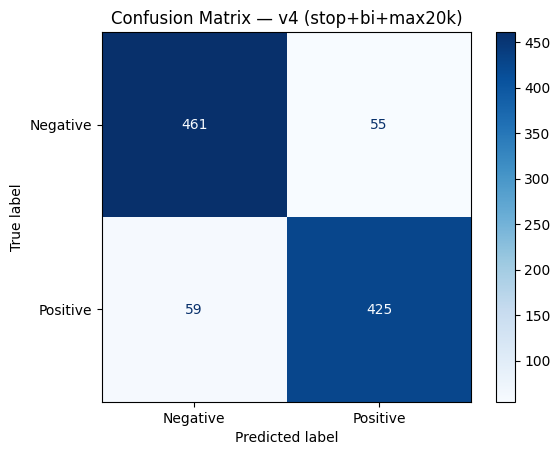

              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89       516
    Positive       0.89      0.88      0.88       484

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



In [13]:
# Find best config by F1
best_name = max(results, key=lambda x: x['f1_score'])['config']
print(f"Best config: {best_name}")

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    test['label'], predictions[best_name],
    display_labels=['Negative', 'Positive'],
    cmap='Blues'
)
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

print(classification_report(test['label'], predictions[best_name], target_names=['Negative', 'Positive']))

### Exercise 4.3 — Summary table

Create a summary `DataFrame` comparing all 4 configs: vocabulary size, accuracy, F1-score.

*Hint:* `pd.DataFrame(results)`

In [14]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('f1_score', ascending=False)
results_df

,config,vocab_size,accuracy,f1_score
3,v4 (stop+bi+max20k),20000,0.886,0.881743
1,v2 (stopwords),30599,0.881,0.877446
2,v3 (bigrams),227195,0.879,0.875897
0,v1 (default),30648,0.875,0.871001


**Question:** Which preprocessing choice has the biggest impact on performance? Why?

**Answer:**
- Adding **bigrams** typically gives the biggest boost — they capture negations ("pas bon", "pas mal") and common phrases ("très bien", "chef d'oeuvre") that unigrams miss.
- **Stopwords removal** has a moderate effect — it reduces noise but can also remove useful signal (e.g., "pas" is a stopword but critical for negation).
- **max_features** helps by filtering out rare, noisy features — it acts as implicit regularization.

---
## 6. Interpretation

One major advantage of Logistic Regression on TF-IDF: the model is **interpretable**. Each feature (word or bigram) has a coefficient — positive coefficients push toward class 1 (positive), negative toward class 0 (negative).

### Exercise 5.1 — Top positive and negative words

Using the best model, extract the top 15 words with the highest positive coefficients and top 15 with the most negative coefficients. Plot them as a horizontal barplot.

*Hint:*
```python
feature_names = best_vectorizer.get_feature_names_out()
coefs = best_model.coef_[0]
top_pos_idx = np.argsort(coefs)[-15:]
top_neg_idx = np.argsort(coefs)[:15]
```

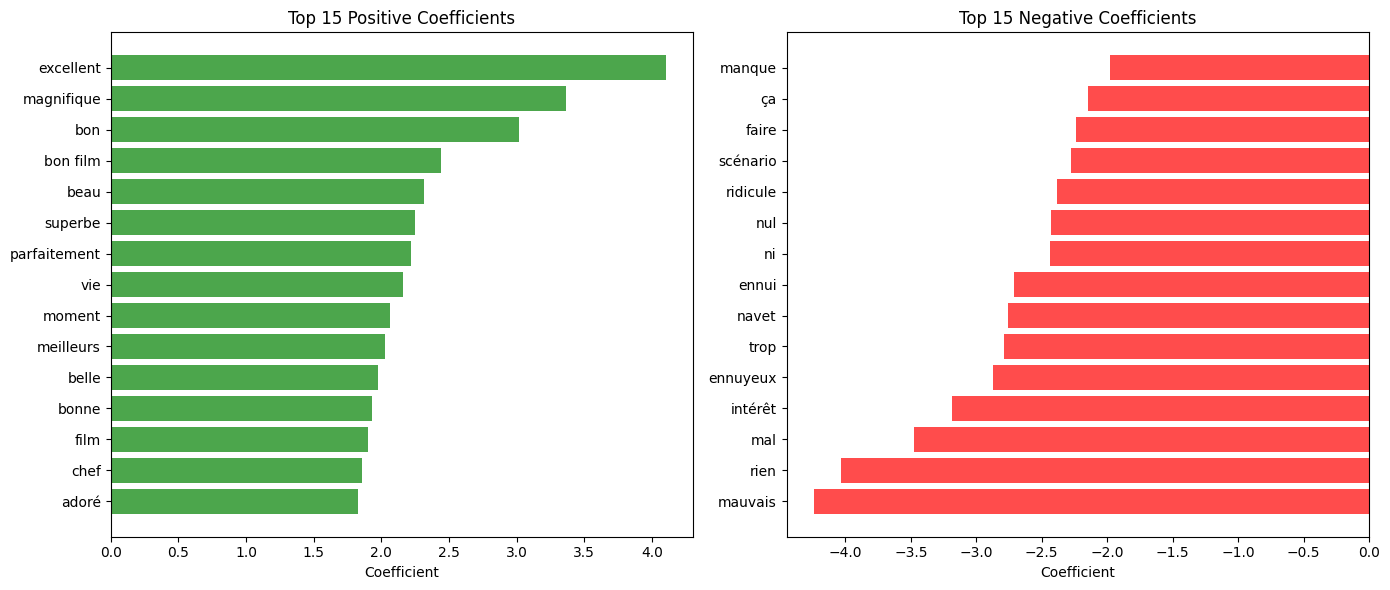

In [15]:
best_vec = fitted_configs[best_name]
best_model = models[best_name]

feature_names = best_vec.get_feature_names_out()
coefs = best_model.coef_[0]

top_pos_idx = np.argsort(coefs)[-15:]
top_neg_idx = np.argsort(coefs)[:15]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive words
axes[0].barh(range(15), coefs[top_pos_idx], color='green', alpha=0.7)
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(feature_names[top_pos_idx])
axes[0].set_title('Top 15 Positive Coefficients')
axes[0].set_xlabel('Coefficient')

# Negative words
axes[1].barh(range(15), coefs[top_neg_idx], color='red', alpha=0.7)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(feature_names[top_neg_idx])
axes[1].set_title('Top 15 Negative Coefficients')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

### Exercise 5.2 — Misclassified reviews

Find 2 misclassified reviews (1 false positive, 1 false negative). Read them and explain why the model might have failed.

**Look for:** irony, negation ("pas mauvais"), mixed sentiment, ambiguity.

*Hint:*
```python
errors = test[test['label'] != y_pred]
false_positives = errors[errors['label'] == 0]
false_negatives = errors[errors['label'] == 1]
```

In [16]:
y_pred_best = predictions[best_name]
test_with_pred = test.copy()
test_with_pred['pred'] = y_pred_best

errors = test_with_pred[test_with_pred['label'] != test_with_pred['pred']]
false_positives = errors[errors['label'] == 0]
false_negatives = errors[errors['label'] == 1]

print(f"Total errors: {len(errors)}")
print(f"False positives (predicted positive, actually negative): {len(false_positives)}")
print(f"False negatives (predicted negative, actually positive): {len(false_negatives)}")

print("\n=== FALSE POSITIVE (predicted positive, actually negative) ===")
if len(false_positives) > 0:
    print(false_positives.iloc[0]['review'][:500])

print("\n=== FALSE NEGATIVE (predicted negative, actually positive) ===")
if len(false_negatives) > 0:
    print(false_negatives.iloc[0]['review'][:500])

Total errors: 114
False positives (predicted positive, actually negative): 55
False negatives (predicted negative, actually positive): 59

=== FALSE POSITIVE (predicted positive, actually negative) ===
Second collaboration de Nia Vardalos et de John Corbett après My Big Fat Greek Wedding! L'histoire, les personnages, l'intrigue ne tiennent pas, Nia Vardalos se force à sourire comme une cruche, John Corbett semble perdu. Mais pourtant ce film est un bon divertissement, mais n'est pas indispensable!

=== FALSE NEGATIVE (predicted negative, actually positive) ===
Je ne vais pas vous écrire que "Freaks" n'a pas pris une ride car comment serait-ce possible pour un film de 1932 !! Mais ce film reste toujours aussi dérangeant et fascinant malgré les années.


---
## 7. Bonus

### Exercise 6.1 — CountVectorizer vs TfidfVectorizer

Replace `TfidfVectorizer` with `CountVectorizer` (same config as your best TF-IDF) and compare.

**Question:** Does TF-IDF weighting help compared to raw counts?

In [17]:
# Use same config as best TF-IDF but with CountVectorizer
count_vec = CountVectorizer(stop_words=french_stopwords, ngram_range=(1, 2), max_features=20000)
X_train_count = count_vec.fit_transform(train['review_clean'])
X_test_count = count_vec.transform(test['review_clean'])

model_count = LogisticRegression(max_iter=1000)
model_count.fit(X_train_count, train['label'])
y_pred_count = model_count.predict(X_test_count)

acc_count = accuracy_score(test['label'], y_pred_count)
f1_count = f1_score(test['label'], y_pred_count)

print(f"CountVectorizer — Accuracy: {acc_count:.4f}   F1: {f1_count:.4f}")
print(f"TfidfVectorizer — Accuracy: {max(results, key=lambda x: x['f1_score'])['accuracy']:.4f}   F1: {max(results, key=lambda x: x['f1_score'])['f1_score']:.4f}")

CountVectorizer — Accuracy: 0.8850   F1: 0.8803
TfidfVectorizer — Accuracy: 0.8860   F1: 0.8817


### Exercise 6.2 — SGDClassifier (linear SVM)

Replace `LogisticRegression` with `SGDClassifier(loss='hinge')` (equivalent to a linear SVM). Compare with Logistic Regression.

*Hint:* `SGDClassifier(loss='hinge', max_iter=1000, random_state=42)`

In [18]:
# Use best vectorizer config
X_train_best = best_vec.transform(train['review_clean'])
X_test_best = best_vec.transform(test['review_clean'])

sgd = SGDClassifier(loss='hinge', max_iter=1000, random_state=42)
sgd.fit(X_train_best, train['label'])
y_pred_sgd = sgd.predict(X_test_best)

acc_sgd = accuracy_score(test['label'], y_pred_sgd)
f1_sgd = f1_score(test['label'], y_pred_sgd)

print(f"SGDClassifier (SVM) — Accuracy: {acc_sgd:.4f}   F1: {f1_sgd:.4f}")
print(f"LogisticRegression  — Accuracy: {max(results, key=lambda x: x['f1_score'])['accuracy']:.4f}   F1: {max(results, key=lambda x: x['f1_score'])['f1_score']:.4f}")

SGDClassifier (SVM) — Accuracy: 0.8900   F1: 0.8875
LogisticRegression  — Accuracy: 0.8860   F1: 0.8817
